In [21]:
# Se importa la clase date de datetime
from datetime import date
# Se importa la libreria Notice_scraper
from notice_scraper import Notice_scraper
# Se importa la libreria NLP_Processing
from nlp_processing import NLP_Processing
import pandas as pd
NLP = NLP_Processing()
# Se carga la fecha actual
today = date.today().strftime("%Y-%m-%d")
# today = "2022-10-30"
# Se instancia el objecto Notice_scraper, indicande el dia de finalizacion y cuantos dias hacia atras se 
# se quiere realizar el scraper, tambien se define el excel que contiene las busquedas de interes.
notices = Notice_scraper(end_date = today, duration = 7, company_list = "Include/First_Names.xlsx", 
                        navegadores_list="Include/user_agent_list.csv")

ModuleNotFoundError: No module named 'torch'

In [24]:
!pip install torch

Looking in indexes: https://artifactory.apps.bancolombia.com/api/pypi/pypi-bancolombia/simple


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch
You should consider upgrading via the 'c:\users\jormora\documents\assenment_managent\assenment\scripts\python.exe -m pip install --upgrade pip' command.


In [23]:
!pip install --upgrade pip

Looking in indexes: https://artifactory.apps.bancolombia.com/api/pypi/pypi-bancolombia/simple
Requirement already up-to-date: pip in c:\users\jormora\documents\assenment_managent\assenment\lib\site-packages (20.2.3)


You should consider upgrading via the 'c:\users\jormora\documents\assenment_managent\assenment\scripts\python.exe -m pip install --upgrade pip' command.


In [1]:
#News = News.sample(n = 20)
# Se utiliza la funcion load_NewYork_files para cargar todos los archivos csv en la ruta indicada
#News = notices.load_files("dataset/")
import pandas as pd
News = pd.read_csv("dataset/Google_News.csv", index_col=None)
News.drop('Unnamed: 0', inplace=True, axis=1)
News.head()

,company,date,media,title,abstract,link,All_Text,label
0,BANK OF AMERICA - BAC - NEWS,2/02/2023,NaN,Capital One Quicksilver Cash Rewards vs. Bank ...,bookmark_border,news.google.com/./articles/CBMiUmh0dHBzOi8vZml...,capital one quicksilver cash rewards vs. bank ...,0
1,BANK OF AMERICA - BAC - NEWS,1/02/2023,NaN,Does Bank of America Corp (BAC) Have What it T...,bookmark_border,news.google.com/./articles/CBMiiAFodHRwczovL3d...,\n\n\n\n\n\n\ndoes bank of america corp (bac) ...,0
2,BANK OF AMERICA - BAC - NEWS,2/02/2023,NaN,Deutsche Bank Q4 pre-tax profit hits 15-year h...,bookmark_border,news.google.com/./articles/CBMiRmh0dHBzOi8vZml...,deutsche bank q4 pre-tax profit hits 15-year h...,1
3,BANK OF AMERICA - BAC - NEWS,2/02/2023,NaN,S&P 500 rises to the highest level in five mon...,bookmark_border,news.google.com/./articles/CBMiTGh0dHBzOi8vd3d...,s&p 500 rises to the highest level in five mon...,1
4,BANK OF AMERICA - BAC - NEWS,1/02/2023,NaN,SBA Loans: Back to Normal,bookmark_border,news.google.com/./articles/CBMiP2h0dHBzOi8vbGF...,\n\nsba loans: back to normal - los angeles b...,1


In [2]:
Train = News[: 46].copy()
Test = News[46 :].copy()
print("Train shape: ", Train.shape)
print("Test shape: ", Test.shape)

Train shape:  (46, 8)
Test shape:  (46, 8)


In [5]:
for new in Test["All_Text"]:
    print(new.split("Tell me only what feeling between positive, negative and neutral has the following news, without justification\n"))
    break








































































st. joseph township sets hearing for nye's property | st joseph | heraldpalladium.com

















skip to main content








×
thank you for reading!






please log in, or sign up for a new account and purchase a subscription to continue reading.




please purchase a subscription to continue reading.



your current subscription does not provide access to this content.





sign up


log in







hp all-access



verify your print or online subscription account here. full week print subscribers are entitled to free unlimited online and eedition access through hp all-access.





                                    free
                                    
                                




verify account







online access



you can purchase a single day to read the paper online or for a better deal, click purchase subscription below to read it for just $10/month!




starting at
                    

In [12]:
Train.to_csv("dataset/Train.csv", index=False)
Test.to_csv("dataset/Test.csv", index=False)

In [6]:
import pandas as pd
from tqdm.notebook import tqdm_notebook
Campo = "All_Text"
Test = NLP.Process_lowcase(Test, [Campo])
out = []
for i in tqdm_notebook(range(len(Test))):
    clean = NLP.Process_symbols_text(Test.iloc[i][Campo])
    clean = NLP.clean_words(clean)
    clean = NLP.clean_patrons(clean)
    separate_text = NLP.separate_tex(clean)
    clean_2 = []
    for part in separate_text:
        temp = NLP.advertising_clean(part)
        if temp != None:
            clean_2.append(temp)
    clean_2 = " ".join(clean_2)
    all_text_simple_sentiment = NLP.simple_sentiment_analisis_text(clean_2)
    all_text_pysentimiento = NLP.pysentimiento_analisis_text(clean_2)
    all_text_finbert = NLP.finbert_sentiment_analisis_text(clean_2)

    sumary = NLP.sumary_text(clean_2, n_tokens=500)

    all_text_simple_sentiment_sumary = NLP.simple_sentiment_analisis_text(sumary)
    all_text_pysentimiento_sumary = NLP.pysentimiento_analisis_text(sumary)
    all_text_finbert_sumary = NLP.finbert_sentiment_analisis_text(sumary)

    clean_2 = NLP.StopWords_text(clean_2)
    sumary = NLP.StopWords_text(sumary)

    clean_2 = " ".join(clean_2.split())
    sumary = " ".join(sumary.split())

    stemer = NLP.snowBallStemmer_text(clean_2)
    stemer_sumary = NLP.snowBallStemmer_text(sumary)

    simple_sentiment = NLP.simple_sentiment_analisis_text(stemer)
    pysentimiento = NLP.pysentimiento_analisis_text(stemer)
    finbert = NLP.finbert_sentiment_analisis_text(stemer)

    simple_sentiment_sumary = NLP.simple_sentiment_analisis_text(stemer_sumary)
    pysentimiento_sumary = NLP.pysentimiento_analisis_text(stemer_sumary)
    finbert_sumary = NLP.finbert_sentiment_analisis_text(stemer_sumary)
    
    out.append([clean_2, stemer, str(simple_sentiment), str(pysentimiento), str(finbert), 
                str(all_text_simple_sentiment), str(all_text_pysentimiento), str(all_text_finbert),
                str(all_text_simple_sentiment_sumary), str(all_text_pysentimiento_sumary),
                str(all_text_finbert_sumary), str(simple_sentiment_sumary), str(pysentimiento_sumary),
                str(finbert_sumary),
                str(int(Test.iloc[i]["label"]))])

out = pd.DataFrame(out, columns=["texto", "stemer", "simple_sentiment", "pysentimiento", "finbert", 
                                "all_text_simple_sentiment", "all_text_pysentimiento", "all_text_finbert",
                                "all_text_simple_sentiment_sumary", "all_text_pysentimiento_sumary",
                                "all_text_finbert_sumary", "simple_sentiment_sumary", 
                                "pysentimiento_sumary", "finbert_sumary",
                                "label"])
results = NLP.get_metrics(out, ["simple_sentiment", "pysentimiento", "finbert", 
                                "all_text_simple_sentiment", "all_text_pysentimiento", "all_text_finbert",
                                "all_text_simple_sentiment_sumary", "all_text_pysentimiento_sumary",
                                "all_text_finbert_sumary", "simple_sentiment_sumary", 
                                "pysentimiento_sumary", "finbert_sumary"],
                                "label")

print(results)

NLP.plot_confusion_matrix(out, ["simple_sentiment", "pysentimiento", "finbert", 
                                "all_text_simple_sentiment", "all_text_pysentimiento", "all_text_finbert", 
                                "all_text_simple_sentiment_sumary", "all_text_pysentimiento_sumary",
                                "all_text_finbert_sumary", "simple_sentiment_sumary", 
                                "pysentimiento_sumary", "finbert_sumary"], 
                                "label")

NameError: name 'NLP' is not defined

In [5]:
!pip install tqdm

Looking in indexes: https://artifactory.apps.bancolombia.com/api/pypi/pypi-bancolombia/simple


You should consider upgrading via the 'c:\users\jormora\documents\assenment_managent\assenment\scripts\python.exe -m pip install --upgrade pip' command.


Looking in indexes: https://artifactory.apps.bancolombia.com/api/pypi/pypi-bancolombia/simple
  Using cached https://artifactory.apps.bancolombia.com/api/pypi/pypi-bancolombia/packages/packages/2a/14/e75e52d521442e2fcc9f1df3c5e456aead034203d4797867980de558ab34/tqdm-4.66.2-py3-none-any.whl (78 kB)


You should consider upgrading via the 'c:\users\jormora\documents\assenment_managent\assenment\scripts\python.exe -m pip install --upgrade pip' command.


In [14]:
import json
out = []
Question = "Tell me only what feeling between positive, negative and neutral has the following news, without justification"
for i in range(len(Train)):
    temp_dict = {}
    text = Question + "\n" + Train.iloc[i]["All_Text"]
    if Train.iloc[i]["label"] == 0:
        label = "The news has a nutral feeling"
    elif Train.iloc[i]["label"] == 1:
        label = "The news has a positive feeling"
    else:
        label = "The news has a negative feeling"
    temp_dict["text"] = text
    temp_dict["label"] = label
    out.append(temp_dict)
final_out = {}
final_out["db"] = out
# Serializing json
json_object = json.dumps(final_out, indent=4)
 
# Writing to sample.json
with open("Train_news.json", "w") as outfile:
    outfile.write(json_object)

In [15]:
import json
out = []
for i in range(len(Test)):
    temp_dict = {}
    id = str(i)
    temp_dict["id"] = id
    temp_dict["text"] = Test.iloc[i]["All_Text"]
    out.append(temp_dict)
final_out = {}
final_out["samples"] = out
# Serializing json
json_object = json.dumps(final_out, indent=4)
 
# Writing to sample.json
with open("Test_news.json", "w") as outfile:
    outfile.write(json_object)

  0%|          | 0/92 [00:00<?, ?it/s]

c:\Users\jormora\Anaconda3\lib\site-packages\transformers\pipelines\text_classification.py:89: UserWarning: `return_all_scores` is now deprecated,  if want a similar funcionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


  Modelo  f1_score  Accuracy
1    0.1  0.554348  0.554348
0   0.05  0.532609  0.532609
2   0.15  0.500000  0.500000
3    0.2  0.489130  0.489130
4   0.25  0.478261  0.478261
6   0.35  0.478261  0.478261
7    0.4  0.478261  0.478261
5    0.3  0.467391  0.467391
0.05


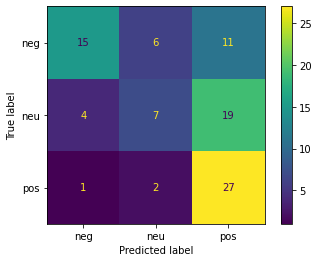

              precision    recall  f1-score   support

         neg       0.75      0.47      0.58        32
         neu       0.47      0.23      0.31        30
         pos       0.47      0.90      0.62        30

   micro avg       0.53      0.53      0.53        92
   macro avg       0.56      0.53      0.50        92
weighted avg       0.57      0.53      0.50        92
 samples avg       0.53      0.53      0.53        92

0.1


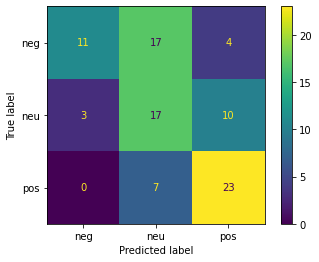

              precision    recall  f1-score   support

         neg       0.79      0.34      0.48        32
         neu       0.41      0.57      0.48        30
         pos       0.62      0.77      0.69        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.61      0.56      0.55        92
weighted avg       0.61      0.55      0.55        92
 samples avg       0.55      0.55      0.55        92

0.15


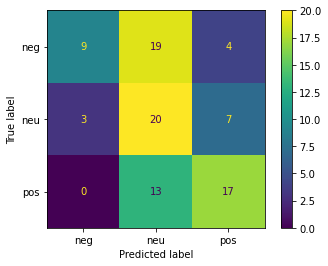

              precision    recall  f1-score   support

         neg       0.75      0.28      0.41        32
         neu       0.38      0.67      0.49        30
         pos       0.61      0.57      0.59        30

   micro avg       0.50      0.50      0.50        92
   macro avg       0.58      0.50      0.49        92
weighted avg       0.58      0.50      0.49        92
 samples avg       0.50      0.50      0.50        92

0.2


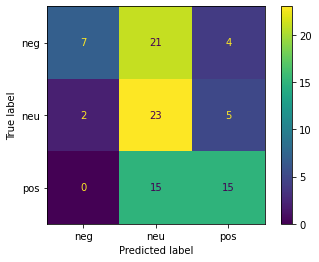

              precision    recall  f1-score   support

         neg       0.78      0.22      0.34        32
         neu       0.39      0.77      0.52        30
         pos       0.62      0.50      0.56        30

   micro avg       0.49      0.49      0.49        92
   macro avg       0.60      0.50      0.47        92
weighted avg       0.60      0.49      0.47        92
 samples avg       0.49      0.49      0.49        92

0.25


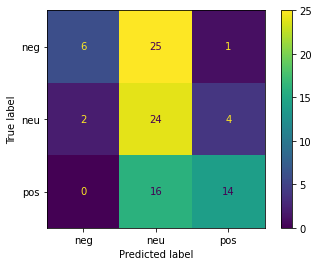

              precision    recall  f1-score   support

         neg       0.75      0.19      0.30        32
         neu       0.37      0.80      0.51        30
         pos       0.74      0.47      0.57        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.62      0.48      0.46        92
weighted avg       0.62      0.48      0.46        92
 samples avg       0.48      0.48      0.48        92

0.3


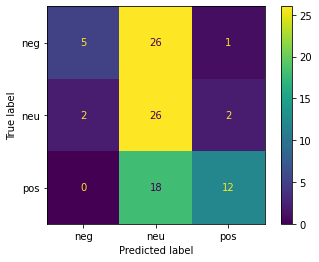

              precision    recall  f1-score   support

         neg       0.71      0.16      0.26        32
         neu       0.37      0.87      0.52        30
         pos       0.80      0.40      0.53        30

   micro avg       0.47      0.47      0.47        92
   macro avg       0.63      0.47      0.44        92
weighted avg       0.63      0.47      0.43        92
 samples avg       0.47      0.47      0.47        92

0.35


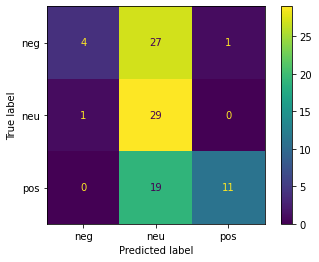

              precision    recall  f1-score   support

         neg       0.80      0.12      0.22        32
         neu       0.39      0.97      0.55        30
         pos       0.92      0.37      0.52        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.70      0.49      0.43        92
weighted avg       0.70      0.48      0.43        92
 samples avg       0.48      0.48      0.48        92

0.4


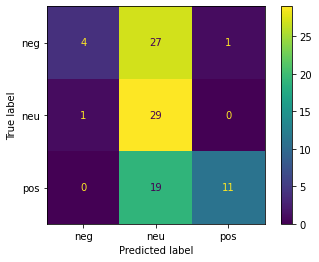

              precision    recall  f1-score   support

         neg       0.80      0.12      0.22        32
         neu       0.39      0.97      0.55        30
         pos       0.92      0.37      0.52        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.70      0.49      0.43        92
weighted avg       0.70      0.48      0.43        92
 samples avg       0.48      0.48      0.48        92



In [4]:
from tqdm.notebook import tqdm_notebook
Campo = "All_Text"
out = []
tresholds = [0.05, 0.1, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4]
names = ["texto"]
for i in tqdm_notebook(range(len(News))):
    out_tresh = []
    clean = NLP.Process_symbols_text(News.iloc[i][Campo])
    clean = NLP.clean_words(clean)
    clean = NLP.clean_patrons(clean)
    separate_text = NLP.separate_tex(clean)
    clean_2 = []
    for part in separate_text:
        temp = NLP.advertising_clean(part)
        if temp != None:
            clean_2.append(temp)
    clean_2 = " ".join(clean_2)
    # Modelo
    all_text_pysentimiento = NLP.pysentimiento_analisis_text(clean_2, True)
    out_tresh.append(clean_2)
    for tresh in tresholds:
        if i == 0:
            names.append(str(tresh))
        NEG = all_text_pysentimiento.probas["NEG"]
        POS = all_text_pysentimiento.probas["POS"]
        if NEG > POS:
            if NEG > tresh:
                out_tresh.append("-1")
            else:
                out_tresh.append("0")
        else:
            if POS > tresh:
                out_tresh.append("1")
            else:
                out_tresh.append("0")
    out_tresh.append(str(News.iloc[i]["label"]))
    out.append(out_tresh)

names.append("label")

out = pd.DataFrame(out, columns=names)
results = NLP.get_metrics(out, names[1:-1],"label")

print(results.sort_values(by=['Accuracy'], ascending=False))

NLP.plot_confusion_matrix(out, names[1:-1], "label")

  0%|          | 0/92 [00:00<?, ?it/s]

c:\Users\jormora\Anaconda3\lib\site-packages\transformers\pipelines\text_classification.py:89: UserWarning: `return_all_scores` is now deprecated,  if want a similar funcionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


  Modelo  f1_score  Accuracy
0   0.05  0.521739  0.521739
1    0.1  0.510870  0.510870
2   0.15  0.478261  0.478261
3    0.2  0.478261  0.478261
4   0.25  0.478261  0.478261
6   0.35  0.478261  0.478261
7    0.4  0.478261  0.478261
5    0.3  0.456522  0.456522
0.05


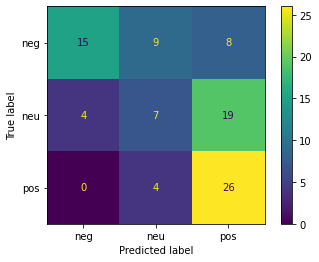

              precision    recall  f1-score   support

         neg       0.79      0.47      0.59        32
         neu       0.35      0.23      0.28        30
         pos       0.49      0.87      0.63        30

   micro avg       0.52      0.52      0.52        92
   macro avg       0.54      0.52      0.50        92
weighted avg       0.55      0.52      0.50        92
 samples avg       0.52      0.52      0.52        92

0.1


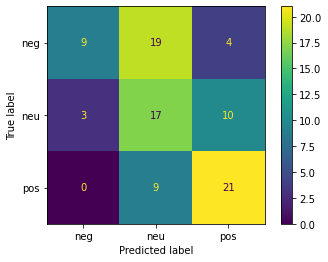

              precision    recall  f1-score   support

         neg       0.75      0.28      0.41        32
         neu       0.38      0.57      0.45        30
         pos       0.60      0.70      0.65        30

   micro avg       0.51      0.51      0.51        92
   macro avg       0.58      0.52      0.50        92
weighted avg       0.58      0.51      0.50        92
 samples avg       0.51      0.51      0.51        92

0.15


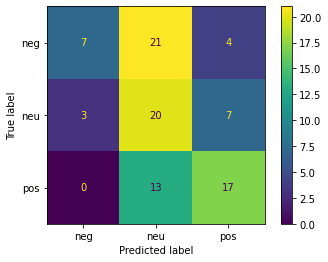

              precision    recall  f1-score   support

         neg       0.70      0.22      0.33        32
         neu       0.37      0.67      0.48        30
         pos       0.61      0.57      0.59        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.56      0.48      0.47        92
weighted avg       0.56      0.48      0.46        92
 samples avg       0.48      0.48      0.48        92

0.2


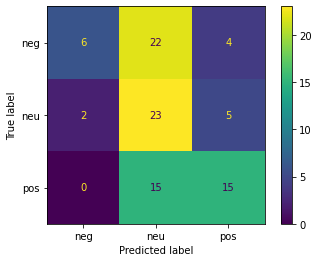

              precision    recall  f1-score   support

         neg       0.75      0.19      0.30        32
         neu       0.38      0.77      0.51        30
         pos       0.62      0.50      0.56        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.59      0.48      0.46        92
weighted avg       0.59      0.48      0.45        92
 samples avg       0.48      0.48      0.48        92

0.25


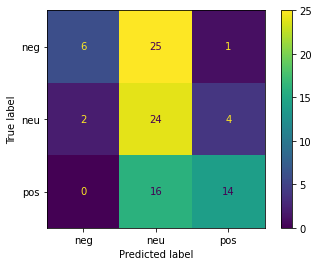

              precision    recall  f1-score   support

         neg       0.75      0.19      0.30        32
         neu       0.37      0.80      0.51        30
         pos       0.74      0.47      0.57        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.62      0.48      0.46        92
weighted avg       0.62      0.48      0.46        92
 samples avg       0.48      0.48      0.48        92

0.3


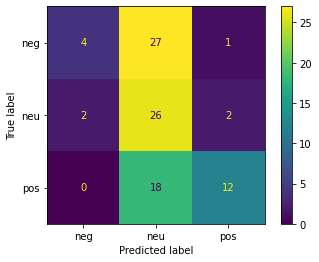

              precision    recall  f1-score   support

         neg       0.67      0.12      0.21        32
         neu       0.37      0.87      0.51        30
         pos       0.80      0.40      0.53        30

   micro avg       0.46      0.46      0.46        92
   macro avg       0.61      0.46      0.42        92
weighted avg       0.61      0.46      0.42        92
 samples avg       0.46      0.46      0.46        92

0.35


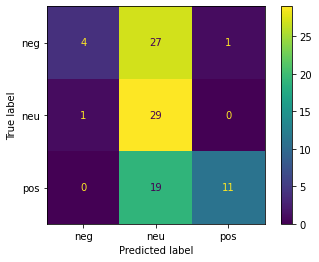

              precision    recall  f1-score   support

         neg       0.80      0.12      0.22        32
         neu       0.39      0.97      0.55        30
         pos       0.92      0.37      0.52        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.70      0.49      0.43        92
weighted avg       0.70      0.48      0.43        92
 samples avg       0.48      0.48      0.48        92

0.4


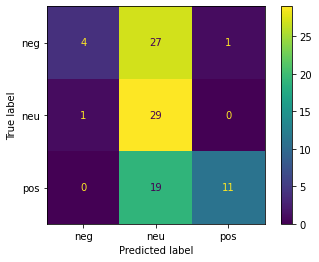

              precision    recall  f1-score   support

         neg       0.80      0.12      0.22        32
         neu       0.39      0.97      0.55        30
         pos       0.92      0.37      0.52        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.70      0.49      0.43        92
weighted avg       0.70      0.48      0.43        92
 samples avg       0.48      0.48      0.48        92



In [5]:
from tqdm.notebook import tqdm_notebook
import numpy as np
Campo = "All_Text"
out = []
tresholds = [0.05, 0.1, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4]
names = ["texto"]
for i in tqdm_notebook(range(len(News))):
    out_tresh = []
    clean = NLP.Process_symbols_text(News.iloc[i][Campo])
    clean = NLP.clean_words(clean)
    clean = NLP.clean_patrons(clean)
    separate_text = NLP.separate_tex(clean)
    clean_2 = []
    for part in separate_text:
        temp = NLP.advertising_clean(part)
        if temp != None:
            clean_2.append(temp)
    clean_2 = " ".join(clean_2)
    # Modelo
    all_text_pysentimiento = NLP.pysentimiento_analisis_text(clean_2, True)
    out_tresh.append(clean_2)
    for tresh in tresholds:
        if i == 0:
            names.append(str(tresh))
        NEG = all_text_pysentimiento.probas["NEG"]
        POS = all_text_pysentimiento.probas["POS"]
        diff = POS - NEG
        if diff < 0:
            if np.abs(diff) > tresh:
                out_tresh.append("-1")
            else:
                out_tresh.append("0")
        else:
            if diff > tresh:
                out_tresh.append("1")
            else:
                out_tresh.append("0")
    out_tresh.append(str(News.iloc[i]["label"]))
    out.append(out_tresh)

names.append("label")

out = pd.DataFrame(out, columns=names)
results = NLP.get_metrics(out, names[1:-1],"label")

print(results.sort_values(by=['Accuracy'], ascending=False))

NLP.plot_confusion_matrix(out, names[1:-1], "label")

In [15]:
result = NLP.finbert_sentiment_analisis_text(clean_2, True)
result.detach().numpy()[0]

array([0.02861938, 0.03759606, 0.9337846 ], dtype=float32)

  0%|          | 0/92 [00:00<?, ?it/s]

c:\Users\jormora\Anaconda3\lib\site-packages\transformers\pipelines\text_classification.py:89: UserWarning: `return_all_scores` is now deprecated,  if want a similar funcionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


        Modelo  f1_score  Accuracy
33   0.1 - 0.9  0.597826  0.597826
14  0.15 - 0.4  0.586957  0.586957
18  0.15 - 0.5  0.576087  0.576087
31   0.2 - 0.8  0.576087  0.576087
28  0.05 - 0.8  0.565217  0.565217
29   0.1 - 0.8  0.565217  0.565217
10  0.15 - 0.3  0.565217  0.565217
5    0.1 - 0.2  0.565217  0.565217
8   0.05 - 0.3  0.554348  0.554348
32  0.05 - 0.9  0.554348  0.554348
21   0.1 - 0.6  0.554348  0.554348
11   0.2 - 0.3  0.554348  0.554348
15   0.2 - 0.4  0.554348  0.554348
16  0.05 - 0.5  0.554348  0.554348
22  0.15 - 0.6  0.554348  0.554348
19   0.2 - 0.5  0.554348  0.554348
25   0.1 - 0.7  0.543478  0.543478
24  0.05 - 0.7  0.543478  0.543478
34  0.15 - 0.9  0.543478  0.543478
23   0.2 - 0.6  0.543478  0.543478
0   0.05 - 0.1  0.543478  0.543478
20  0.05 - 0.6  0.543478  0.543478
13   0.1 - 0.4  0.543478  0.543478
12  0.05 - 0.4  0.543478  0.543478
9    0.1 - 0.3  0.543478  0.543478
17   0.1 - 0.5  0.532609  0.532609
26  0.15 - 0.7  0.532609  0.532609
4   0.05 - 0.2  0.53

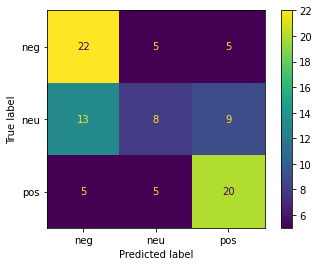

              precision    recall  f1-score   support

         neg       0.55      0.69      0.61        32
         neu       0.44      0.27      0.33        30
         pos       0.59      0.67      0.62        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.53      0.54      0.52        92
weighted avg       0.53      0.54      0.53        92
 samples avg       0.54      0.54      0.54        92

0.1 - 0.1


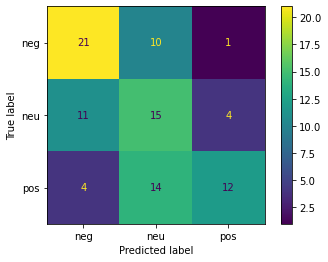

              precision    recall  f1-score   support

         neg       0.58      0.66      0.62        32
         neu       0.38      0.50      0.43        30
         pos       0.71      0.40      0.51        30

   micro avg       0.52      0.52      0.52        92
   macro avg       0.56      0.52      0.52        92
weighted avg       0.56      0.52      0.52        92
 samples avg       0.52      0.52      0.52        92

0.15 - 0.1


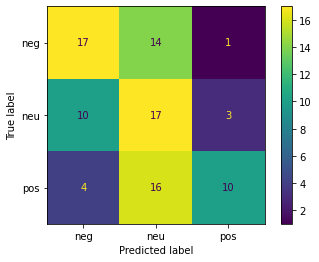

              precision    recall  f1-score   support

         neg       0.55      0.53      0.54        32
         neu       0.36      0.57      0.44        30
         pos       0.71      0.33      0.45        30

   micro avg       0.48      0.48      0.48        92
   macro avg       0.54      0.48      0.48        92
weighted avg       0.54      0.48      0.48        92
 samples avg       0.48      0.48      0.48        92

0.2 - 0.1


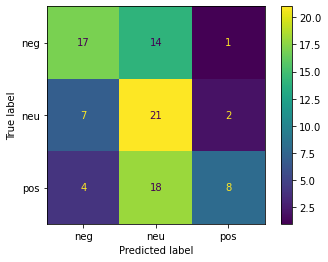

              precision    recall  f1-score   support

         neg       0.61      0.53      0.57        32
         neu       0.40      0.70      0.51        30
         pos       0.73      0.27      0.39        30

   micro avg       0.50      0.50      0.50        92
   macro avg       0.58      0.50      0.49        92
weighted avg       0.58      0.50      0.49        92
 samples avg       0.50      0.50      0.50        92

0.05 - 0.2


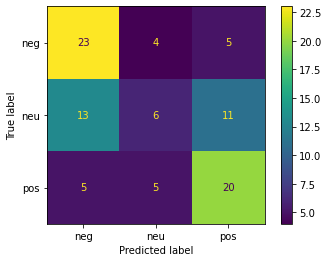

              precision    recall  f1-score   support

         neg       0.56      0.72      0.63        32
         neu       0.40      0.20      0.27        30
         pos       0.56      0.67      0.61        30

   micro avg       0.53      0.53      0.53        92
   macro avg       0.51      0.53      0.50        92
weighted avg       0.51      0.53      0.50        92
 samples avg       0.53      0.53      0.53        92

0.1 - 0.2


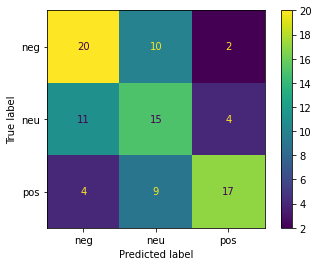

              precision    recall  f1-score   support

         neg       0.57      0.62      0.60        32
         neu       0.44      0.50      0.47        30
         pos       0.74      0.57      0.64        30

   micro avg       0.57      0.57      0.57        92
   macro avg       0.58      0.56      0.57        92
weighted avg       0.58      0.57      0.57        92
 samples avg       0.57      0.57      0.57        92

0.15 - 0.2


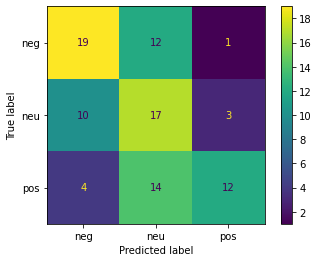

              precision    recall  f1-score   support

         neg       0.58      0.59      0.58        32
         neu       0.40      0.57      0.47        30
         pos       0.75      0.40      0.52        30

   micro avg       0.52      0.52      0.52        92
   macro avg       0.57      0.52      0.52        92
weighted avg       0.57      0.52      0.53        92
 samples avg       0.52      0.52      0.52        92

0.2 - 0.2


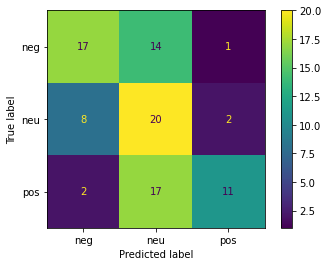

              precision    recall  f1-score   support

         neg       0.63      0.53      0.58        32
         neu       0.39      0.67      0.49        30
         pos       0.79      0.37      0.50        30

   micro avg       0.52      0.52      0.52        92
   macro avg       0.60      0.52      0.52        92
weighted avg       0.60      0.52      0.52        92
 samples avg       0.52      0.52      0.52        92

0.05 - 0.3


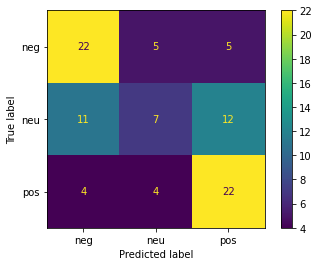

              precision    recall  f1-score   support

         neg       0.59      0.69      0.64        32
         neu       0.44      0.23      0.30        30
         pos       0.56      0.73      0.64        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.53      0.55      0.53        92
weighted avg       0.53      0.55      0.53        92
 samples avg       0.55      0.55      0.55        92

0.1 - 0.3


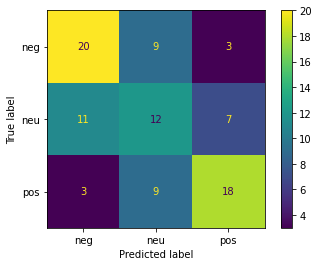

              precision    recall  f1-score   support

         neg       0.59      0.62      0.61        32
         neu       0.40      0.40      0.40        30
         pos       0.64      0.60      0.62        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.54      0.54      0.54        92
weighted avg       0.54      0.54      0.54        92
 samples avg       0.54      0.54      0.54        92

0.15 - 0.3


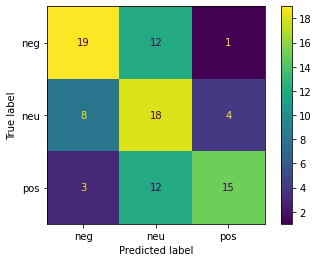

              precision    recall  f1-score   support

         neg       0.63      0.59      0.61        32
         neu       0.43      0.60      0.50        30
         pos       0.75      0.50      0.60        30

   micro avg       0.57      0.57      0.57        92
   macro avg       0.60      0.56      0.57        92
weighted avg       0.60      0.57      0.57        92
 samples avg       0.57      0.57      0.57        92

0.2 - 0.3


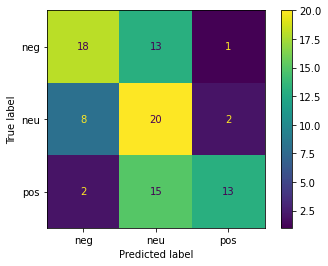

              precision    recall  f1-score   support

         neg       0.64      0.56      0.60        32
         neu       0.42      0.67      0.51        30
         pos       0.81      0.43      0.57        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.62      0.55      0.56        92
weighted avg       0.62      0.55      0.56        92
 samples avg       0.55      0.55      0.55        92

0.05 - 0.4


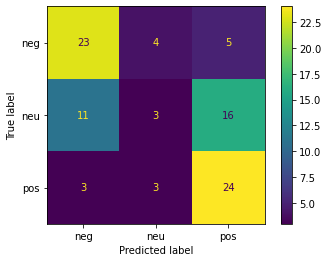

              precision    recall  f1-score   support

         neg       0.62      0.72      0.67        32
         neu       0.30      0.10      0.15        30
         pos       0.53      0.80      0.64        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.48      0.54      0.49        92
weighted avg       0.49      0.54      0.49        92
 samples avg       0.54      0.54      0.54        92

0.1 - 0.4


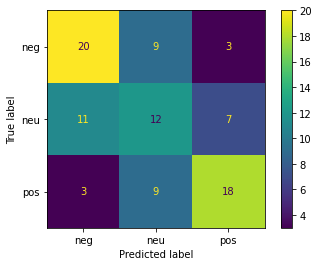

              precision    recall  f1-score   support

         neg       0.59      0.62      0.61        32
         neu       0.40      0.40      0.40        30
         pos       0.64      0.60      0.62        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.54      0.54      0.54        92
weighted avg       0.54      0.54      0.54        92
 samples avg       0.54      0.54      0.54        92

0.15 - 0.4


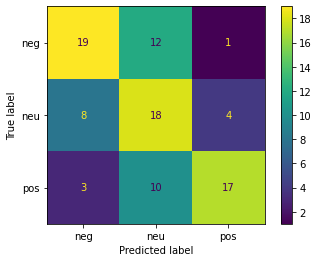

              precision    recall  f1-score   support

         neg       0.63      0.59      0.61        32
         neu       0.45      0.60      0.51        30
         pos       0.77      0.57      0.65        30

   micro avg       0.59      0.59      0.59        92
   macro avg       0.62      0.59      0.59        92
weighted avg       0.62      0.59      0.59        92
 samples avg       0.59      0.59      0.59        92

0.2 - 0.4


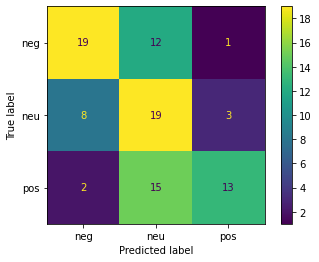

              precision    recall  f1-score   support

         neg       0.66      0.59      0.62        32
         neu       0.41      0.63      0.50        30
         pos       0.76      0.43      0.55        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.61      0.55      0.56        92
weighted avg       0.61      0.55      0.56        92
 samples avg       0.55      0.55      0.55        92

0.05 - 0.5


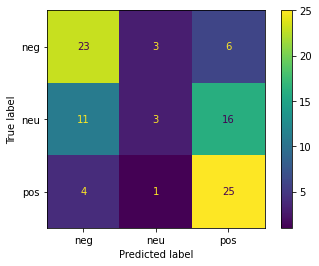

              precision    recall  f1-score   support

         neg       0.61      0.72      0.66        32
         neu       0.43      0.10      0.16        30
         pos       0.53      0.83      0.65        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.52      0.55      0.49        92
weighted avg       0.52      0.55      0.49        92
 samples avg       0.55      0.55      0.55        92

0.1 - 0.5


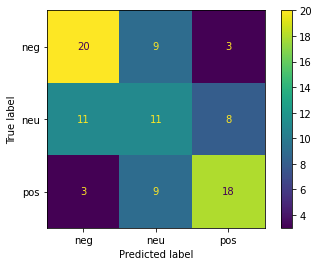

              precision    recall  f1-score   support

         neg       0.59      0.62      0.61        32
         neu       0.38      0.37      0.37        30
         pos       0.62      0.60      0.61        30

   micro avg       0.53      0.53      0.53        92
   macro avg       0.53      0.53      0.53        92
weighted avg       0.53      0.53      0.53        92
 samples avg       0.53      0.53      0.53        92

0.15 - 0.5


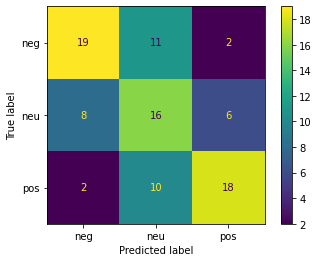

              precision    recall  f1-score   support

         neg       0.66      0.59      0.62        32
         neu       0.43      0.53      0.48        30
         pos       0.69      0.60      0.64        30

   micro avg       0.58      0.58      0.58        92
   macro avg       0.59      0.58      0.58        92
weighted avg       0.59      0.58      0.58        92
 samples avg       0.58      0.58      0.58        92

0.2 - 0.5


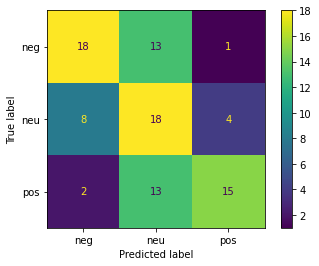

              precision    recall  f1-score   support

         neg       0.64      0.56      0.60        32
         neu       0.41      0.60      0.49        30
         pos       0.75      0.50      0.60        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.60      0.55      0.56        92
weighted avg       0.60      0.55      0.56        92
 samples avg       0.55      0.55      0.55        92

0.05 - 0.6


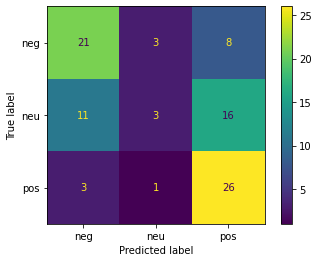

              precision    recall  f1-score   support

         neg       0.60      0.66      0.63        32
         neu       0.43      0.10      0.16        30
         pos       0.52      0.87      0.65        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.52      0.54      0.48        92
weighted avg       0.52      0.54      0.48        92
 samples avg       0.54      0.54      0.54        92

0.1 - 0.6


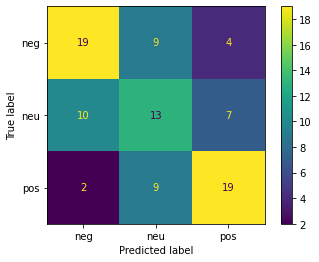

              precision    recall  f1-score   support

         neg       0.61      0.59      0.60        32
         neu       0.42      0.43      0.43        30
         pos       0.63      0.63      0.63        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.56      0.55      0.55        92
weighted avg       0.56      0.55      0.56        92
 samples avg       0.55      0.55      0.55        92

0.15 - 0.6


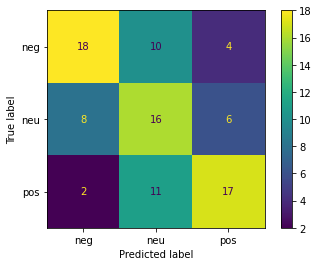

              precision    recall  f1-score   support

         neg       0.64      0.56      0.60        32
         neu       0.43      0.53      0.48        30
         pos       0.63      0.57      0.60        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.57      0.55      0.56        92
weighted avg       0.57      0.55      0.56        92
 samples avg       0.55      0.55      0.55        92

0.2 - 0.6


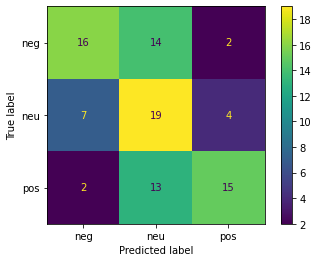

              precision    recall  f1-score   support

         neg       0.64      0.50      0.56        32
         neu       0.41      0.63      0.50        30
         pos       0.71      0.50      0.59        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.59      0.54      0.55        92
weighted avg       0.59      0.54      0.55        92
 samples avg       0.54      0.54      0.54        92

0.05 - 0.7


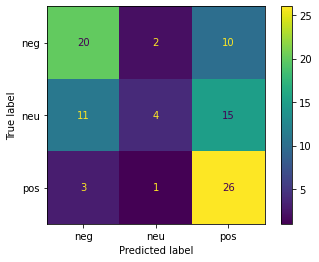

              precision    recall  f1-score   support

         neg       0.59      0.62      0.61        32
         neu       0.57      0.13      0.22        30
         pos       0.51      0.87      0.64        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.56      0.54      0.49        92
weighted avg       0.56      0.54      0.49        92
 samples avg       0.54      0.54      0.54        92

0.1 - 0.7


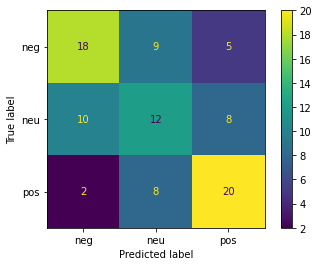

              precision    recall  f1-score   support

         neg       0.60      0.56      0.58        32
         neu       0.41      0.40      0.41        30
         pos       0.61      0.67      0.63        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.54      0.54      0.54        92
weighted avg       0.54      0.54      0.54        92
 samples avg       0.54      0.54      0.54        92

0.15 - 0.7


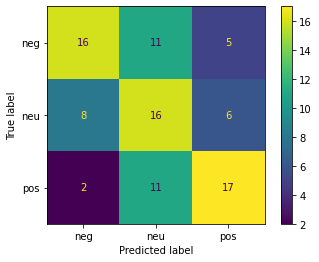

              precision    recall  f1-score   support

         neg       0.62      0.50      0.55        32
         neu       0.42      0.53      0.47        30
         pos       0.61      0.57      0.59        30

   micro avg       0.53      0.53      0.53        92
   macro avg       0.55      0.53      0.54        92
weighted avg       0.55      0.53      0.54        92
 samples avg       0.53      0.53      0.53        92

0.2 - 0.7


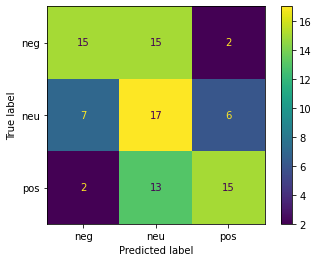

              precision    recall  f1-score   support

         neg       0.62      0.47      0.54        32
         neu       0.38      0.57      0.45        30
         pos       0.65      0.50      0.57        30

   micro avg       0.51      0.51      0.51        92
   macro avg       0.55      0.51      0.52        92
weighted avg       0.55      0.51      0.52        92
 samples avg       0.51      0.51      0.51        92

0.05 - 0.8


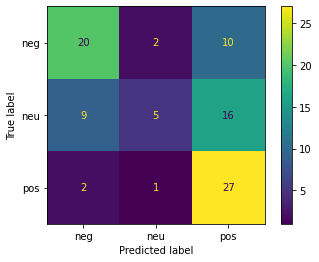

              precision    recall  f1-score   support

         neg       0.65      0.62      0.63        32
         neu       0.62      0.17      0.26        30
         pos       0.51      0.90      0.65        30

   micro avg       0.57      0.57      0.57        92
   macro avg       0.59      0.56      0.52        92
weighted avg       0.59      0.57      0.52        92
 samples avg       0.57      0.57      0.57        92

0.1 - 0.8


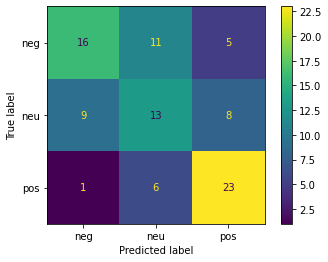

              precision    recall  f1-score   support

         neg       0.62      0.50      0.55        32
         neu       0.43      0.43      0.43        30
         pos       0.64      0.77      0.70        30

   micro avg       0.57      0.57      0.57        92
   macro avg       0.56      0.57      0.56        92
weighted avg       0.56      0.57      0.56        92
 samples avg       0.57      0.57      0.57        92

0.15 - 0.8


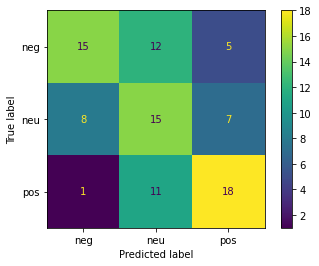

              precision    recall  f1-score   support

         neg       0.62      0.47      0.54        32
         neu       0.39      0.50      0.44        30
         pos       0.60      0.60      0.60        30

   micro avg       0.52      0.52      0.52        92
   macro avg       0.54      0.52      0.53        92
weighted avg       0.54      0.52      0.53        92
 samples avg       0.52      0.52      0.52        92

0.2 - 0.8


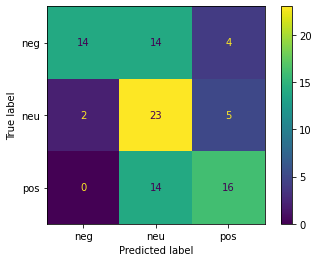

              precision    recall  f1-score   support

         neg       0.88      0.44      0.58        32
         neu       0.45      0.77      0.57        30
         pos       0.64      0.53      0.58        30

   micro avg       0.58      0.58      0.58        92
   macro avg       0.66      0.58      0.58        92
weighted avg       0.66      0.58      0.58        92
 samples avg       0.58      0.58      0.58        92

0.05 - 0.9


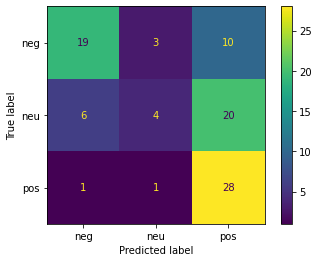

              precision    recall  f1-score   support

         neg       0.73      0.59      0.66        32
         neu       0.50      0.13      0.21        30
         pos       0.48      0.93      0.64        30

   micro avg       0.55      0.55      0.55        92
   macro avg       0.57      0.55      0.50        92
weighted avg       0.57      0.55      0.50        92
 samples avg       0.55      0.55      0.55        92

0.1 - 0.9


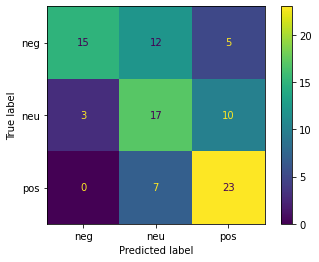

              precision    recall  f1-score   support

         neg       0.83      0.47      0.60        32
         neu       0.47      0.57      0.52        30
         pos       0.61      0.77      0.68        30

   micro avg       0.60      0.60      0.60        92
   macro avg       0.64      0.60      0.60        92
weighted avg       0.64      0.60      0.60        92
 samples avg       0.60      0.60      0.60        92

0.15 - 0.9


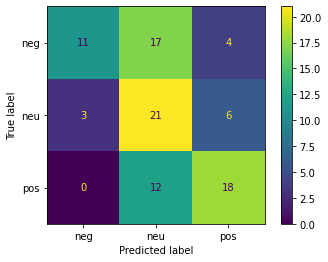

              precision    recall  f1-score   support

         neg       0.79      0.34      0.48        32
         neu       0.42      0.70      0.53        30
         pos       0.64      0.60      0.62        30

   micro avg       0.54      0.54      0.54        92
   macro avg       0.62      0.55      0.54        92
weighted avg       0.62      0.54      0.54        92
 samples avg       0.54      0.54      0.54        92

0.2 - 0.9


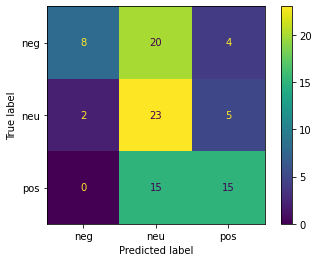

              precision    recall  f1-score   support

         neg       0.80      0.25      0.38        32
         neu       0.40      0.77      0.52        30
         pos       0.62      0.50      0.56        30

   micro avg       0.50      0.50      0.50        92
   macro avg       0.61      0.51      0.49        92
weighted avg       0.61      0.50      0.48        92
 samples avg       0.50      0.50      0.50        92



In [6]:
from tqdm.notebook import tqdm_notebook
Campo = "All_Text"
out = []
tresholds = [0.05, 0.1, 0.15]
weights = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
names = ["texto"]
for i in tqdm_notebook(range(len(News))):
    
    clean = NLP.Process_symbols_text(News.iloc[i][Campo])
    clean = NLP.clean_words(clean)
    clean = NLP.clean_patrons(clean.lower())
    separate_text = NLP.separate_tex(clean)
    clean_2 = []
    for part in separate_text:
        temp = NLP.advertising_clean(part)
        if temp != None:
            clean_2.append(temp)
    clean_2 = " ".join(clean_2)
    # Modelo
    all_text_pysentimiento = NLP.pysentimiento_analisis_text(clean_2, True)
    alltext_finbert = NLP.finbert_sentiment_analisis_text(clean_2, True)
    out_tresh = []
    out_tresh.append(clean_2)
    for weight in weights:     
        POS, NEG = NLP.assembler_model(all_text_pysentimiento, alltext_finbert.detach().numpy(), weight)

        for tresh in tresholds:
            if i == 0:
                names.append(str(tresh) + " - " + str(weight))
            if NEG > POS:
                if NEG > tresh:
                    out_tresh.append("-1")
                else:
                    out_tresh.append("0")
            else:
                if POS > tresh:
                    out_tresh.append("1")
                else:
                    out_tresh.append("0")
    out_tresh.append(str(News.iloc[i]["label"]))
    out.append(out_tresh)

names.append("label")

out = pd.DataFrame(out, columns=names)
results = NLP.get_metrics(out, names[1:-1],"label")

print(results.sort_values(by=['Accuracy'], ascending=False))

NLP.plot_confusion_matrix(out, names[1:-1], "label")

In [11]:
url = "https://www.xda-developers.com/best-apple-ipad-air-5-screen-protectors/"
news = notices.scraping(url)
df = pd.DataFrame([["Apple", "02/06/2023", None, 
            "Best Apple iPad Air 5 screen protectors in 2023",
            "xda-developers", url, news, 1]], columns=["company", "date", "media", "title", "abstract", "link", 
            "All_Text", "label"])
News = News.append(df,  ignore_index=True)
News.to_csv("dataset/Google_News.csv")
News.label.value_counts()


 1    33
-1    32
 0    32
Name: label, dtype: int64

In [20]:
import socket
import requests as req
proxy = socket.gethostbyname(socket.gethostname())
url = "https://www.rd.com/list/apple-deals/"
response=req.get(url, proxies={"http": proxy, "https": proxy})

ProxyError: HTTPSConnectionPool(host='www.rd.com', port=443): Max retries exceeded with url: /list/apple-deals/ (Caused by ProxyError('Cannot connect to proxy.', NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x000001AC383F61F0>: Failed to establish a new connection: [WinError 10061] No se puede establecer una conexión ya que el equipo de destino denegó expresamente dicha conexión')))

In [3]:
import pandas as pd
dataset = pd.read_csv("dataset/Google_News.csv", index_col=None)
dataset = dataset.drop(['Unnamed: 0'], axis=1)

In [17]:
dataset.iloc[1]

company                          BANK OF AMERICA - BAC - NEWS
date                                                1/02/2023
media                                                     NaN
title       Does Bank of America Corp (BAC) Have What it T...
abstract                                      bookmark_border
link        news.google.com/./articles/CBMiiAFodHRwczovL3d...
All_Text    \n\n\n\n\n\n\ndoes bank of america corp (bac) ...
label                                                       0
Name: 1, dtype: object

In [22]:
out = {}
for i in range(len(dataset)):
    out[i] = {"Title": dataset.iloc[i]["title"],
              "Text": dataset.iloc[i]["All_Text"],
              "Link": dataset.iloc[i]["link"],
              "Label": int(dataset.iloc[i]["label"])}

In [23]:
import json
with open('dataset/sentiment_dataset.json', 'w') as f:
    json.dump(out, f)